### ENSIMAG – Grenoble INP – UGA - Academic year 2025-2026
# Introduction to Statistical Learning and Applications ([website](https://github.com/ISLA-Grenoble/2025-main))

- Pedro L. C. Rodrigues -- `pedro.rodrigues@inria.fr`

- Isabella Costa Maia -- `isabella.costa-maia@grenoble-inp.fr`

- Pierre Marrec -- `pierre.marrec@inria.fr`

***

### ⚠️ General guidelines for TPs

The report should contain graphical representations and explanatory text. For each graph, axis names should be provided as well
as a legend when it is appropriate. Figures should be explained by a few sentences in the text. Answer to
the questions in order and refer to the question number in your report. Computations and
graphics have to be performed in `python`. The report should be written as a jupyter notebook. This is a file format that allows users to format documents containing text written in markdown and `python` instructions. You should include all of the `python` instructions that you have used in the document so that it may be possible to replicate your results.

***

# 🖥️ TP2: Principal components regression in genetics

The goal of this TP session is to use genetic markers to predict the geographical origin of a set of indians from South, Central, and North America. We propose to build two regression linear models to predict the latitude and longitude of an individual based on its genetic markers. Because the number of markers (p = 5709) is larger than the number of samples (N = 494), the predictors of the regression model will be the outputs of a principal component analysis (PCA) performed on the genetic markers. A genetic marker is encoded 1 if the individual has a mutation, 0 elsewhere.

## ▶️ Exercise 1: Data visualization (1 point)

NB: To do this exercise you will have to install packages `geopandas` and `geodatasets`.

Download dataset `NAm2.txt` from [here](https://github.com/ISLA-Grenoble/2025-main/blob/main/TP/TP2/NAm2.txt). Each row of the dataset corresponds to an individual and the columns have explicit names. The third column contains the names of the tribes to which each individual pertains. Columns 7 and 8 contain the latitude and the longitude and from Column 9 onwards are genetic markers, which are encoded are 0 or 1. Run the code described below and explain how it works.

```
import pandas as pd
import geopandas as gpd
import geodatasets
import matplotlib.pyplot as plt

# Load the data
file_path = 'NAm2.txt'
df = pd.read_csv(file_path, delimiter=' ')

# Extract relevant columns
latitude = df.iloc[:, 6]
longitude = df.iloc[:, 7]
tribes = df.iloc[:, 2]

# Create a GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(longitude, latitude))

# Plotting
world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]
for i, tribe in enumerate(gdf['Pop'].unique()):
    members_tribe = gdf[gdf['Pop'] == tribe]
    ax.scatter(members_tribe['long'], members_tribe['lat'], 
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe)
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Tribes Locations')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
fig.show()
```

/tmp/ipykernel_341282/3859679900.py:36: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


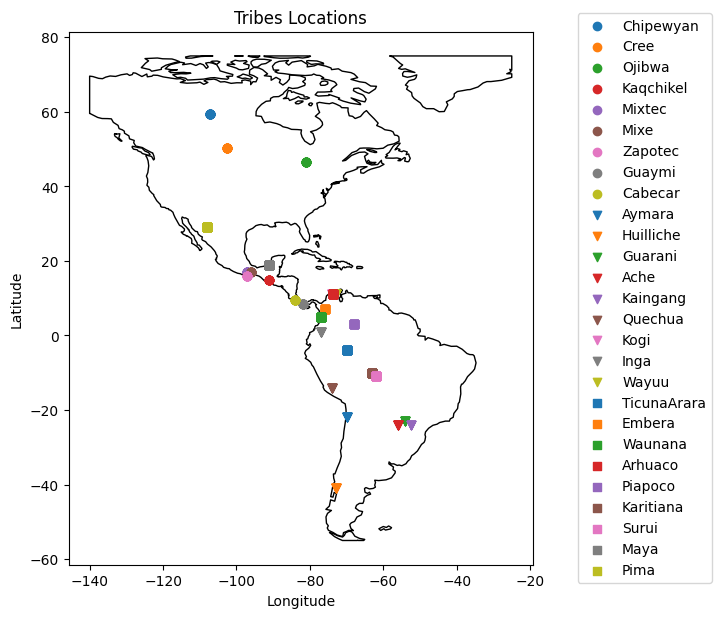

In [1]:

import geopandas as gpd
import geodatasets
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


# Load the data
file_path = 'NAm2.txt'
df = pd.read_csv(file_path, delimiter=' ')

# Extract relevant columns
latitude = df.iloc[:, 6]
longitude = df.iloc[:, 7]
tribes = df.iloc[:, 2]

# Create a GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(longitude, latitude))

# Plotting
world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]
for i, tribe in enumerate(gdf['Pop'].unique()):
    members_tribe = gdf[gdf['Pop'] == tribe]
    ax.scatter(members_tribe['long'], members_tribe['lat'], 
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe)
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Tribes Locations')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
fig.show()

## Code Explanation

This code reads geographic data from `NAm2.txt` and plots the locations of different populations on a map of the Americas.

First, the dataset is loaded into a pandas DataFrame. Latitude and longitude values are extracted and converted into geographic points using GeoPandas, creating a `GeoDataFrame`.

Then, a land map from the Natural Earth dataset is used as a background. The map is clipped to the region of interest, corresponding roughly to the Americas.

Each population in the `Pop` column is plotted separately with a different color and marker, allowing visual comparison of their spatial distribution.


## ▶️ Exercise 2: Multiple linear regression (2 points)

Using **only** the genetic markers as predictors, you will estimate a multiple linear regression model to predict the longitude of each individual.

You will proceed in several steps.

**(a)** First, try to estimate the coefficients of the multiple linear regression using the expression seen in class 

$$\hat{\beta} = (X^\top X)^{-1}X^\top y$$

You should proceed as we did in TP1 using `numpy.linalg.solve` to obtain the values of $\beta$. 

Did you run into any errors? What is going on? Relate your answer to the fact that $\text{rank}(X) < p$, where $X \in R^{N*p}$ is the data matrix.

In [3]:
# longitude
y = df.iloc[:, 7].to_numpy()

# genetic markers
X = df.iloc[:, 8:].to_numpy()

# This fails because X.T @ X is singular: rank(X) < p since p = 5709 > N = 494
beta_hat = np.linalg.solve(X.T @ X, X.T @ y)

LinAlgError: Singular matrix

As expected, `numpy.linalg.solve` raises a singular matrix error. The root cause is that the number of predictors (`p = 5709`) far exceeds the number of samples (`N = 494`), so `X` cannot have full column rank. Since `rank(X) < p`, the columns of `X` are linearly dependent and  $$(X^\top X)$$ is singular. The formula

$$
\hat{\beta} = (X^\top X)^{-1} X^\top y
$$

therefore cannot be applied directly to this problem.

**(b)** Use function `numpy.linalg.lstsq` to estimate the coefficients (it may take a few seconds to get a result). 

And now? Did you get any errors? Why is that? 

Relate your answer to the difference between functions `numpy.linalg.solve` and `numpy.linalg.lstsq`.

You can check the documention for both functions as well as [this](https://netlib.org/lapack/lug/node27.html) link for more information.

In [4]:
beta_hat = np.linalg.lstsq(X, y)[0]
beta_hat

array([-0.04005781, -0.01940898,  0.01111306, ..., -0.21729626,
       -0.10210421,  0.01813644], shape=(5709,))

This time no error is raised. `numpy.linalg.lstsq` does not attempt to invert `X⊤X` explicitly; instead it computes a minimum-norm least-squares solution via a numerically stable factorization, typically the singular value decomposition. This approach works even when the system is rectangular or rank-deficient.

The key difference with `solve` is that `solve` requires a square, full-rank system, whereas `lstsq` is designed precisely for ill-conditioned or underdetermined problems like this one.

 **(c)** We will now use `sklearn` to do our linear regression with the help of class `sklearn.linear_model.LinearRegression` whose documentation is available [here](https://scikit-learn.org/1.5/modules/generated/sklearn.linear_model.LinearRegression.html). Note that every estimator from `sklearn` has a `fit` and a `predict` method, which are used to calculate coefficients and predict values (see [here](https://scikit-learn.org/stable/getting_started.html#fitting-and-predicting-estimator-basics) for more info). In our current case, we can do:

```
# select only the genetic markers as predictors
predictors = df.columns[8:]
# create the design matrix
X = df[predictors].values
# get the observed values to predict
y = df['long']
# fit a multiple linear regression model
lr = LinearRegression()
lr.fit(X, y)
```

You should not run into errors now, since `sklearn` also uses `lstsq` to solve the normal equations, as shown [here](https://github.com/scikit-learn/scikit-learn/blob/d666202a9349893c1bd106cc9ee0ff0a807c7cf3/sklearn/linear_model/_base.py#L682) (though it uses the `scipy` implementation instead of the `numpy` for "historical" reasons). Check the values of the estimated coefficients stored as an attribute in `lr.coef_`, are they the same as the ones obtained in item **(b)**? Probably not. This is because `sklearn` re-centers the predictors before estimating the coefficients of the linear regression, as shown [here](https://github.com/scikit-learn/scikit-learn/blob/d666202a9349893c1bd106cc9ee0ff0a807c7cf3/sklearn/linear_model/_base.py#L622). What would be a practical reason for doing such re-centering systematically? Hint: it has to do with how to interpret the intercept of the model. 

In [5]:
from sklearn.linear_model import LinearRegression
# select only the genetic markers as predictors
predictors = df.columns[8:]
# create the design matrix
X = df[predictors].values
# get the observed values to predict
y = df['long']
# fit a multiple linear regression model
lr = LinearRegression(fit_intercept=True)
lr.fit(X, y)
print("Coefficients:", lr.coef_)
print("beta_hat", beta_hat)

Coefficients: [-0.03940988 -0.0245272   0.01089763 ...  0.04804479 -0.08985062
  0.01903025]
beta_hat [-0.04005781 -0.01940898  0.01111306 ... -0.21729626 -0.10210421
  0.01813644]


### (c)

Using `LinearRegression`, no error is obtained. This is expected because `sklearn` fits ordinary least squares using a least-squares solver rather than solving $$X^\top X \beta = X^\top y$$ with an exact inverse, so it can handle rank-deficient matrices.

The coefficients in `lr.coef_` are usually not exactly the same as in part (b), because `sklearn` centers the data when `fit_intercept=True`. In its preprocessing step, it centers both **X** and **y**, and then reconstructs the intercept afterward.

A practical reason for this re-centering is that the intercept becomes easier to interpret: it corresponds to the predicted value when the predictors are at their average level. It also improves numerical stability when fitting the model.

## ▶️ Exercise 3: Principal components analysis (5 points)

**(a)** Explain in a few words the main concepts and ideas underlying the principal component analysis (PCA). You should include both the geometric and statistical interpretations of PCA.

### (a) Main ideas of PCA

Principal Component Analysis (PCA) is a dimension-reduction method that transforms a set of possibly correlated variables into a new set of orthogonal variables called **principal components**.

From a **geometric point of view**, PCA finds new axes in the feature space such that:
- the first principal component is the direction along which the data vary the most,
- the second principal component is orthogonal to the first one and explains the largest remaining variability

So PCA can be seen as a rotation of the coordinate system that aligns the axes with the main directions of the data cloud.

From a **statistical point of view**, PCA constructs linear combinations of the original variables that maximize the variance. The first components contain most of the information in the data, while later components often correspond to noise or less important variation.

As a result, PCA is often used to summarize high-dimensional data with only a few components, while keeping most of the variability of the original dataset.

**(b)** Use the estimator defined in `sklearn.decomposition.PCA` to do a PCA on the dataset. Plot the first two dimensions of the projected data points on a scatterplot. The scattered points should have different markers and colors depending on which tribe they belong to. You can use the same color/marker style from **Exercise 2** or propose a new one.

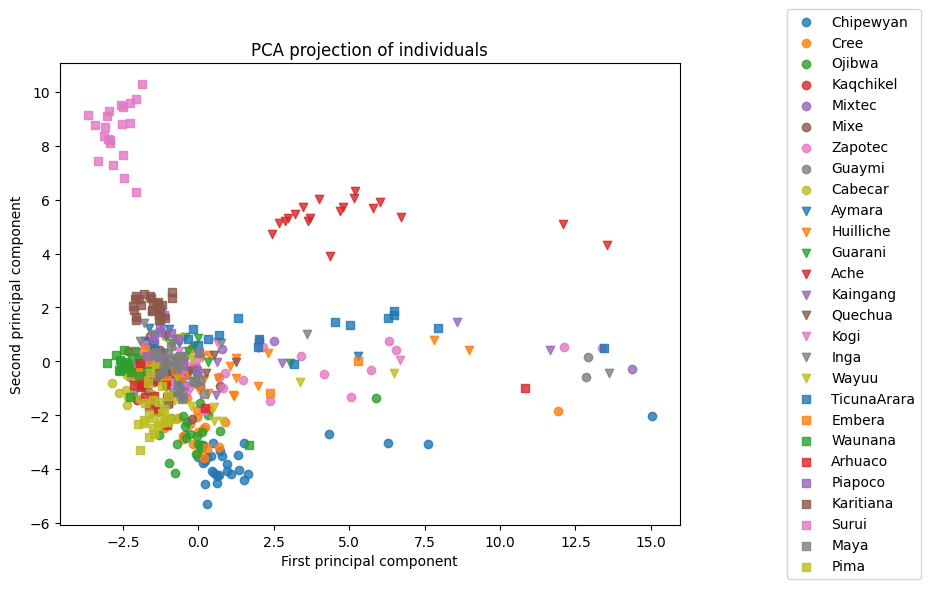

Explained variance ratio: [0.02050031 0.01518413]


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


predictors = df.columns[8:]
X = df[predictors].values


pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

fig, ax = plt.subplots(figsize=(8, 6))


for i, tribe in enumerate(tribes.unique()):
    mask = tribes == tribe
    ax.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        marker=marker_list[i // 9],
        color=colors_list[i % 9],
        label=tribe,
        alpha=0.8
    )

ax.set_title("PCA projection of individuals")
ax.set_xlabel("First principal component")
ax.set_ylabel("Second principal component")
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)

**(c)** Remember from our class that the results of PCA are affected when pre-processing transformations are applied to the data. We will illustrate this using `sklearn.preprocessing.StandardScaler` as per:
```
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X)
X_std = scaler.transform(X)
```
Redo the 2D scatter plot from item **(b)** on the normalized version of the datast. How does it compare to your previous plot?

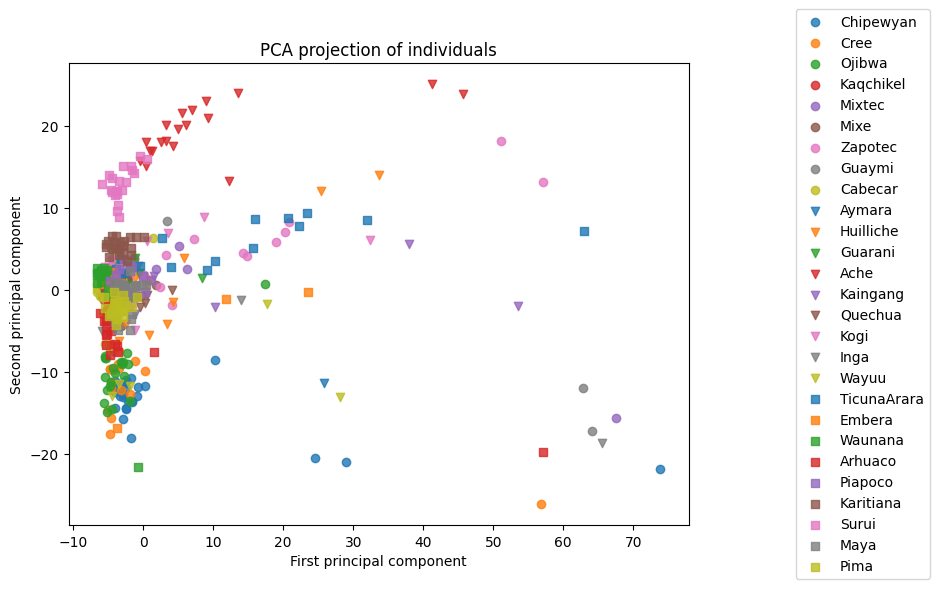

Explained variance ratio: [0.02367493 0.01025403]


In [8]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X)
X_std = scaler.transform(X)


pca = PCA(n_components=2)
X_std_pca = pca.fit_transform(X_std)

fig, ax = plt.subplots(figsize=(8, 6))


for i, tribe in enumerate(tribes.unique()):
    mask = tribes == tribe
    ax.scatter(
        X_std_pca[mask, 0],
        X_std_pca[mask, 1],
        marker=marker_list[i // 9],
        color=colors_list[i % 9],
        label=tribe,
        alpha=0.8
    )

ax.set_title("PCA projection of individuals")
ax.set_xlabel("First principal component")
ax.set_ylabel("Second principal component")
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)

### (c) PLots comparison

After standardization, the main population structure is still visible, but the plot tends to be less clean and more influenced by low-variance markers. Because the markers are binary and already on the same scale (0/1), standardization does not address a unit mismatch. What it does instead is inflate the contribution of rare mutations, which carry less information about geographical origin. The structure in the PCA plane therefore becomes noisier.

**(d)** Given the results in **(b)** and **(c)**, what can you conclude regarding the necessity of standardizing the data points for the dataset consider in this TP?

### (d) Conclusion

For this dataset, standardization is not necessary and is likely counterproductive. All genetic markers are already coded as 0/1, so they share the same scale by construction. Standardizing them over-weights rare variants and blurs the geographic structure captured by the first principal components. PCA on the raw marker matrix is therefore the more appropriate choice.

**(e)** Which percentage of variance is captured by the first two principal components? How many principal components would you keep if you would like to represent the genetic markers using a minimal number of principal components? To help answering this question, you can use a plot showing the cumulative percentage of variance as a function of the number of principal components.

In [9]:
pct_2pc = 100 * np.sum(pca.explained_variance_ratio_[:2])
print(f"Percentage explained by the first two PCs: {pct_2pc:.2f}%")

Percentage explained by the first two PCs: 3.39%


Maximum number of PCs to plot: 494


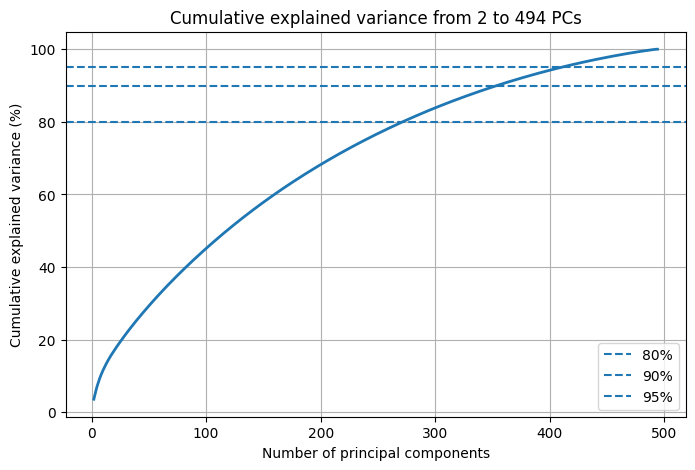

In [10]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

X_data = X

pca = PCA()
X_pca = pca.fit_transform(X_data)


cum_var = 100 * np.cumsum(pca.explained_variance_ratio_)


max_k = min(X_data.shape[0], X_data.shape[1])
print("Maximum number of PCs to plot:", max_k)

k_values = np.arange(2, max_k + 1)

plt.figure(figsize=(8, 5))
plt.plot(k_values, cum_var[1:max_k], linewidth=2)
plt.axhline(80, linestyle="--", label="80%")
plt.axhline(90, linestyle="--", label="90%")
plt.axhline(95, linestyle="--", label="95%")
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance (%)")
plt.title(f"Cumulative explained variance from 2 to {max_k} PCs")
plt.legend()
plt.grid(True)
plt.show()

In [11]:
k80 = np.argmax(cum_var >= 80) + 1
k90 = np.argmax(cum_var >= 90) + 1
k95 = np.argmax(cum_var >= 95) + 1

print("PCs for 80%:", k80)
print("PCs for 90%:", k90)
print("PCs for 95%:", k95)

PCs for 80%: 272
PCs for 90%: 354
PCs for 95%: 410


### (e) Answer
The first two principal components explain only 3.39\% of the variance. From the cumulative explained variance curve, we observe that:

- 272 principal components are needed to explain about 80\% of the variance,
- 354 principal components are needed to explain about 90\%,
- 410 principal components are needed to explain about 95\%.

Therefore, two principal components are clearly not sufficient to summarize the dataset. If we want to represent the genetic markers with a minimal number of principal components while preserving most of the information, a reasonable choice would be 354 components for a 90\% explained variance threshold.

## ▶️ Exercise 4: Principal components regression (4 points)

**(a)** Predict the latitude and the longitude of all points from the dataset using the scores of the first 250 PCA axes. Plot the predicted spatial coordinates using the same style and structure from **Exercise 1** and compare the results from each plot. What can you conclude? Does the new map illustrate somehow too optimistically (or too pessimistically) the ability to find geographical origin of individuals outside the database from its genetic markers? Justify your answer.

/tmp/ipykernel_341282/1673077958.py:34: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


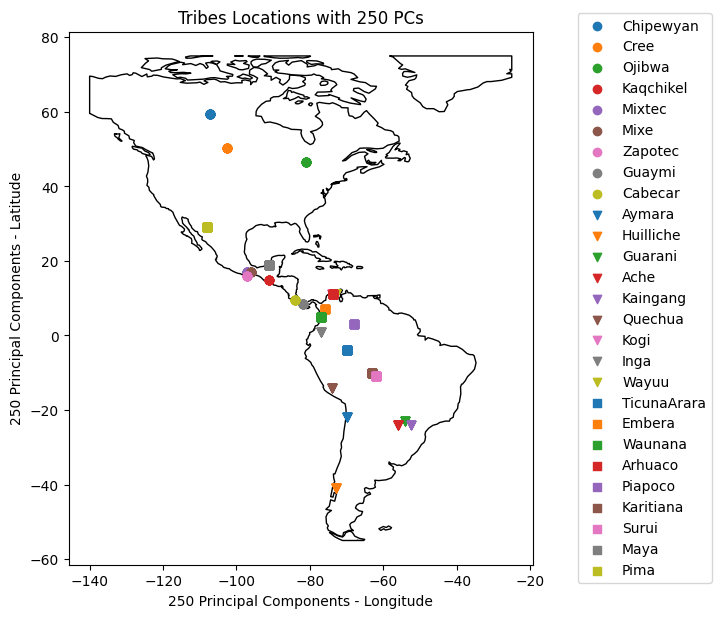

In [12]:
pca = PCA(n_components=250)
X_pca = pca.fit_transform(X)

lr_lat = LinearRegression()
lr_lat.fit(X_pca, latitude)
lat_pred = lr_lat.predict(X_pca)

lr_long = LinearRegression()
lr_long.fit(X_pca, longitude)
long_pred = lr_long.predict(X_pca)

df_pred = df.copy()
df_pred["lat_pred"] = lat_pred
df_pred["long_pred"] = long_pred


gdf = gpd.GeoDataFrame(df_pred, geometry=gpd.points_from_xy(long_pred, lat_pred))

world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]
for i, tribe in enumerate(gdf['Pop'].unique()):
    members_tribe = gdf[gdf['Pop'] == tribe]
    ax.scatter(members_tribe['long'], members_tribe['lat'], 
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe)
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Tribes Locations with 250 PCs')
ax.set_xlabel('250 Principal Components - Longitude')
ax.set_ylabel('250 Principal Components - Latitude')
fig.show()

With 250 principal components, the predicted map is visually close to the true one: the model is flexible enough to recover most of the spatial structure present in the data. However, this result is overly optimistic for predicting unseen individuals, because both the PCA and the regression were fitted on the very same observations that are being evaluated. This in-sample evaluation systematically overestimates true out-of-sample performance.

**(b)** Quantify the error of the linear regression model using the mean distance between real and predicted coordinates. Beware to use `sklearn.metrics.pairwise.haversine_distances` so to correctly measure the distances between points so to take into account the curvature of the Earth. Your answer should be given in kilometers.

In [13]:
from sklearn.metrics.pairwise import haversine_distances


real_coords = df_pred[["lat", "long"]].to_numpy()
pred_coords = df_pred[["lat_pred", "long_pred"]].to_numpy()


real_coords_rad = np.radians(real_coords)
pred_coords_rad = np.radians(pred_coords)


dist_matrix = haversine_distances(real_coords_rad, pred_coords_rad)

earth_radius_km = 6371.0087714 
dist_km = np.diag(dist_matrix) * earth_radius_km


mean_error_km = dist_km.mean()

print(f"Mean distance error: {mean_error_km:.2f} km")

Mean distance error: 644.29 km


## ▶️ Exercise 5: PCR and cross-validation (6 points)

Our goal now is to build the best model to predict individual geographical coordinates. 

For this, you will run a linear regression to predict latitudes and longitudes. Note that `sklearn.linear_model.LinearRegression` can naturally handle the fact of having two sets of coefficients. We will use ten-fold cross-validation to helps us choose the number of principal axes that we should keep. You should report the errors in terms of kilometers as done in **Exercise 4(b)**.

**(a)** Recall in a few words the principle of cross-validation. Explain why this procedure is useful when building a predictive model. Your answer should mention different strategies to handle datasets in which the samples are not IID.

Cross-validation consists in splitting the dataset into several parts, fitting the model on one subset and evaluating it on data that were not used for training. Repeating this across several folds gives an estimate of the prediction error on unseen data. This is useful for model selection because it helps detect overfitting and allows us to compare several values of the tuning parameter, here the number of principal components.

When samples are not IID, the split must respect the dependency structure. For grouped data, one should use grouped cross-validation; for spatially dependent data, blocked splits are often more appropriate; and for time-dependent data, one should use time-series splits that preserve chronology. Otherwise, leakage between train and test sets can lead to overly optimistic results.

**(b)** Based on the structure of the dataset being used, such as the different countries of the individuals and the order in which the rows of the dataframe are provided, explain which choice of cross-validation iterator from [here](https://scikit-learn.org/stable/modules/cross_validation.html#cross-validation-iterators) seems the most adequate for our context.

The most appropriate iterator here is `GroupKFold`, using the tribe or population label as the grouping variable. The rows are ordered by populations, and individuals from the same tribe are not independent because they share both a common geographical origin and a similar genetic background. A random split would place very similar individuals in both training and test sets, which would make the task artificially easier. `GroupKFold` avoids this issue by keeping each tribe entirely within one fold.

**(c)** We first assess the quality of the PCR fit for `n_components=4`. Note that you should be careful in avoiding [data leakage](https://scikit-learn.org/stable/common_pitfalls.html#data-leakage) problems when doing the PCA followed by a multiple linear regression. You should use the pipeline interface from scikit-learn with `sklearn.pipeline.make_pipeline` to facilitate your task. Be sure to evaluate the errors as done in **Exercise 4(b)**.

In [14]:

from sklearn.model_selection import GroupKFold
from sklearn.pipeline import make_pipeline


y = df[["lat", "long"]].values


groups = df.iloc[:, 1].values

cv = GroupKFold(n_splits=10)

pipe = make_pipeline(
    PCA(n_components=4),
    LinearRegression()
)

y_pred_oof = np.zeros_like(y, dtype=float)
fold_errors_km = []

for fold, (train_idx, test_idx) in enumerate(cv.split(X, y, groups=groups), start=1):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    y_pred_oof[test_idx] = y_pred

    # Haversine distance for this fold
    dist_matrix = haversine_distances(
        np.radians(y_test),
        np.radians(y_pred)
    )
    dist_km = np.diag(dist_matrix) * earth_radius_km
    fold_mean_km = dist_km.mean()
    fold_errors_km.append(fold_mean_km)

    print(f"Fold {fold}: mean error = {fold_mean_km:.2f} km")

# Overall cross-validated error
dist_matrix_all = haversine_distances(
    np.radians(y),
    np.radians(y_pred_oof)
)
dist_km_all = np.diag(dist_matrix_all) * earth_radius_km

mean_error_km = dist_km_all.mean()
std_error_km = dist_km_all.std()

print(f"\nOverall mean CV error: {mean_error_km:.2f} km")
print(f"Overall std of pointwise errors: {std_error_km:.2f} km")
print(f"Mean of fold errors: {np.mean(fold_errors_km):.2f} km")

Fold 1: mean error = 3776.97 km
Fold 2: mean error = 2535.30 km
Fold 3: mean error = 1180.38 km
Fold 4: mean error = 1739.98 km
Fold 5: mean error = 2244.30 km
Fold 6: mean error = 3176.51 km
Fold 7: mean error = 2805.78 km
Fold 8: mean error = 2147.53 km
Fold 9: mean error = 1187.12 km
Fold 10: mean error = 2947.64 km

Overall mean CV error: 2394.60 km
Overall std of pointwise errors: 1606.36 km
Mean of fold errors: 2374.15 km


**(d)** Repeat the analysis from item **(b)** but changing `n_components` between 2 and 440 in steps of 10. Plot the mean training and test errors versus the number of principal components. Attention, the errors should be given in kilometers.

In [21]:

X = df.iloc[:, 8:].values

y = df[["lat", "long"]].values

groups = df.iloc[:, 1].values

cv = GroupKFold(n_splits=10)
cv_splits = list(cv.split(X, y, groups=groups))

earth_radius_km = 6371.0

def mean_haversine_km(y_true, y_pred):
    dist_matrix = haversine_distances(
        np.radians(y_true),
        np.radians(y_pred)
    )
    return np.diag(dist_matrix).mean() * earth_radius_km

n_components_grid = list(range(2, 441, 10))
if n_components_grid[-1] != 440:
    n_components_grid.append(440)

min_train_size = min(len(train_idx) for train_idx, _ in cv_splits)
max_valid_components = min(440, X.shape[1], min_train_size)
n_components_grid = [k for k in n_components_grid if k <= max_valid_components]

mean_train_errors = []
mean_test_errors = []

for n_comp in n_components_grid:
    fold_train_errors = []
    fold_test_errors = []

    pipe = make_pipeline(
        PCA(n_components=n_comp),
        LinearRegression()
    )

    for train_idx, test_idx in cv_splits:
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        pipe.fit(X_train, y_train)

        y_train_pred = pipe.predict(X_train)
        y_test_pred = pipe.predict(X_test)

        train_error_km = mean_haversine_km(y_train, y_train_pred)
        test_error_km = mean_haversine_km(y_test, y_test_pred)

        fold_train_errors.append(train_error_km)
        fold_test_errors.append(test_error_km)

    mean_train_errors.append(np.mean(fold_train_errors))
    mean_test_errors.append(np.mean(fold_test_errors))



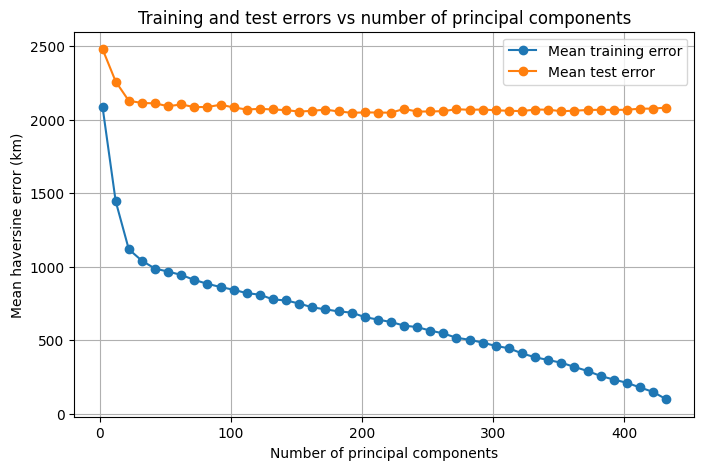

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(n_components_grid, mean_train_errors, marker="o", label="Mean training error")
plt.plot(n_components_grid, mean_test_errors, marker="o", label="Mean test error")
plt.xlabel("Number of principal components")
plt.ylabel("Mean haversine error (km)")
plt.title("Training and test errors vs number of principal components")
plt.legend()
plt.grid(True)
plt.show()

In [23]:
# Best number of PCs according to test error
best_idx = np.argmin(mean_test_errors)
best_n_components = n_components_grid[best_idx]
best_test_error = mean_test_errors[best_idx]
best_train_error = mean_train_errors[best_idx]

print(f"Best number of PCs: {best_n_components}")
print(f"Best mean test error: {best_test_error:.2f} km")
print(f"Best mean train error: {best_train_error:.2f} km")

Best number of PCs: 192
Best mean test error: 2046.90 km
Best mean train error: 688.96 km


(e)** Which model would you keep? What is the prediction error for this model? Compare it with its corresponding training error. Plot the predicted coordinates on a map as in **Exercise 4(a)**. What can you conclude?**

I would keep the PCR model with **192** principal components, since it gives the lowest mean cross-validated test error.

The prediction error of this model is **2046.90 km**

Its corresponding mean training error is **688.96 km**


/tmp/ipykernel_341282/2624184427.py:55: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


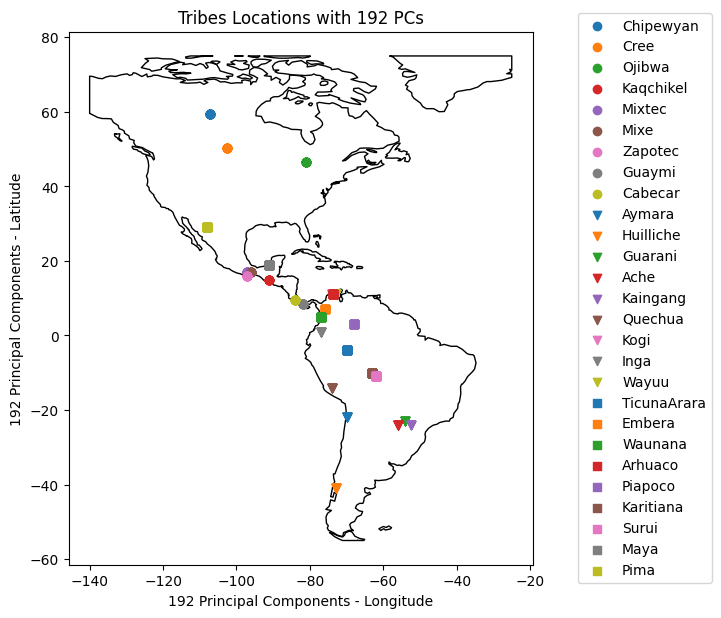

In [24]:

X = df.iloc[:, 8:].values
y = df[["lat", "long"]].values
groups = df.iloc[:, 1].values 

cv = GroupKFold(n_splits=10)
pipe = make_pipeline(
    PCA(n_components=best_n_components),
    LinearRegression()
)


y_pred_oof = np.zeros_like(y, dtype=float)
train_errors = []
test_errors = []

for train_idx, test_idx in cv.split(X, y, groups=groups):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    pipe.fit(X_train, y_train)

    y_train_pred = pipe.predict(X_train)
    y_test_pred = pipe.predict(X_test)

    train_errors.append(mean_haversine_km(y_train, y_train_pred))
    test_errors.append(mean_haversine_km(y_test, y_test_pred))

    y_pred_oof[test_idx] = y_test_pred

# Store predictions
df_pred_cv = df.copy()
df_pred_cv["lat_pred"] = y_pred_oof[:, 0]
df_pred_cv["long_pred"] = y_pred_oof[:, 1]


# Create a GeoDataFrame
gdf = gpd.GeoDataFrame(df_pred_cv, geometry=gpd.points_from_xy(df_pred_cv["long_pred"], df_pred_cv["lat_pred"]))

# Plotting
world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]
for i, tribe in enumerate(gdf['Pop'].unique()):
    members_tribe = gdf[gdf['Pop'] == tribe]
    ax.scatter(members_tribe['long'], members_tribe['lat'], 
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe)
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title(f'Tribes Locations with {best_n_components} PCs')
ax.set_xlabel(f'{best_n_components} Principal Components - Longitude')
ax.set_ylabel(f'{best_n_components} Principal Components - Latitude')
fig.show()

The predicted map obtained with the model using **192** principal components is visually very close to the one obtained with **250** components, and both maps look almost identical to the original map. This suggests that the model is able to reproduce the spatial structure of the training data very well.

However, this visual result is misleading if taken alone. The cross-validation results show that the best model still has a mean test error of **2046.90 km**


which is much larger than its mean training error, **688.96 km**.


So, even though the map looks very accurate, the model does not generalize nearly as well to unseen individuals. The map is therefore too optimistic as an illustration of predictive performance.

In conclusion, the PCR model captures some relationship between genetic markers and geographical origin, but its true prediction ability on new individuals remains limited. Cross-validation gives a more realistic assessment than the visual appearance of the fitted map.

## ▶️ Exercise 6: Conclusion (2 points)

Propose a conclusion to your study. You can write a paragraph about the quality of predictors versus the number of factors, possible improvements to the approach (for instance, showing what happens when using [partial least squares](https://scikit-learn.org/1.5/auto_examples/cross_decomposition/plot_pcr_vs_pls.html) instead of PCR), comment on the performance of the regression in predictions for each country separately, etc. Note that we expect a thorough presentation of the final predictive model as well as an interpretation of it, not simply a bunch of `python` code lines.

## Conclusion

In this study, we investigated whether genetic markers can be used to predict the geographical origin of individuals through principal components regression. The exploratory analysis showed that the first two principal components capture only a small fraction of the total variance, which means that the genetic information is spread across many directions. This was confirmed by the cumulative explained variance curve, which indicated that a large number of principal components is required to summarize the marker matrix well. In practice, the predictive performance improved when the number of components increased, but only up to a point. The training error kept decreasing steadily as more components were added, whereas the test error decreased at first and then stabilized. This shows the usual trade-off between model flexibility and generalization. According to cross-validation, the best model was obtained with **192** principal components. Its mean test error was about **2046.90** km, while its mean training error was only **688.96** km. This large gap shows that the model fits the training data much better than unseen data, so the visual impression given by the fitted maps is too optimistic if taken as a measure of real predictive performance.

Overall, the results indicate that genetic markers do contain information related to broad geographic origin, since the regression is able to recover part of the large-scale spatial structure of the dataset. However, the prediction remains too imprecise for accurate localization of new individuals. A mean error above **2000** km suggests that the model is better at capturing continental or regional trends than exact origin. The study also highlights the importance of using a proper validation strategy: in-sample predictions can look almost perfect, but cross-validation reveals a much more realistic level of performance. For this dataset, standardization was not strictly necessary because the markers are binary variables coded on the same scale, although it still changed the PCA representation by modifying the relative weight of markers with different variances.

Several improvements could be explored. A natural extension would be to compare PCR with Partial Least Squares, since PLS uses the response variables when constructing the components and may therefore produce more predictive low-dimensional representations. It would also be interesting to analyze prediction errors separately by country or population, because the model may perform better in some regions than others, especially where the genetic structure is more distinct. More generally, the final conclusion is that PCR provides a useful baseline and reveals a genuine relationship between genetics and geography, but its predictive power for unseen individuals remains limited and should be interpreted with caution.